# ShelfSight — Shelf Metrics
**Upload these 3 files to Colab before running (folder icon on left → upload):**
1. `saad_best.pt` — Saad's trained model
2. `test_shelf.jpg` — the shelf photo to analyse
3. `planogram.jpg` — your reference planogram photo

Then run all cells top to bottom.


### Step 1 — Install and import

In [1]:
%pip install ultralytics --quiet

from ultralytics import YOLO
from pathlib import Path
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Done.


### Step 2 — Load model and configure brands

In [6]:
model = YOLO("saad_best.pt")

CLASS_NAMES    = model.names
OUR_BRAND      = "coca-cola"           # your brand
COMPETITORS    = ["fanta", "sprite"]   # competitor brands
CONF           = 0.4                   # detection confidence threshold
GRID_ROWS      = 2                     # shelf rows for planogram grid
GRID_COLS      = 5                     # shelf columns for planogram grid

print("Model loaded.")
print(f"Classes : {CLASS_NAMES}")
print(f"Brand   : {OUR_BRAND}")
print(f"Competitors: {COMPETITORS}")

Model loaded.
Classes : {0: 'coca-cola', 1: 'fanta', 2: 'sprite'}
Brand   : coca-cola
Competitors: ['fanta', 'sprite']


### Step 3 — Detect products on shelf

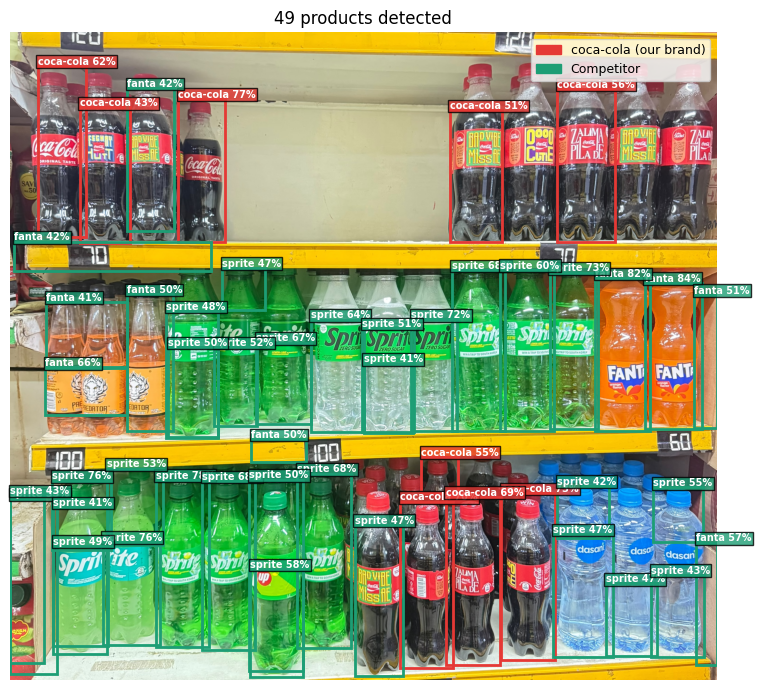

Detected 49 products total.


In [7]:
TEST_IMAGE = "test2.jpg"

results    = model.predict(source=TEST_IMAGE, conf=CONF, verbose=False)
result     = results[0]
img_w      = result.orig_shape[1]
img_h      = result.orig_shape[0]

detections = []
for box in result.boxes:
    cls_id = int(box.cls)
    name   = CLASS_NAMES[cls_id]
    x1, y1, x2, y2 = map(float, box.xyxy[0])
    detections.append({
        "class":    name,
        "conf":     float(box.conf),
        "bbox":     (x1, y1, x2, y2),
        "center_x": (x1+x2)/2,
        "center_y": (y1+y2)/2,
    })

# Draw detections
fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(Image.open(TEST_IMAGE))

for d in detections:
    x1, y1, x2, y2 = d["bbox"]
    color = "#E53935" if d["class"] == OUR_BRAND else "#1D9E75"
    ax.add_patch(patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor=color, facecolor="none"))
    ax.text(x1, y1-5, f"{d['class']} {d['conf']*100:.0f}%",
            color="white", fontsize=7, fontweight="bold",
            bbox=dict(facecolor=color, alpha=0.8, pad=1))

ax.legend(handles=[
    patches.Patch(color="#E53935", label=f"{OUR_BRAND} (our brand)"),
    patches.Patch(color="#1D9E75", label="Competitor"),
], loc="upper right", fontsize=9)
ax.set_title(f"{len(detections)} products detected", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig("detected.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Detected {len(detections)} products total.")

### Step 4 — Share of Shelf (SOS)

SHARE OF SHELF (SOS)
  coca-cola         : 9 facings
  fanta             : 10 facings
  sprite            : 30 facings
  Total             : 49 facings
  SOS              : 18.4%
  Formula: coke facings / total facings x 100
  Status: POOR — brand is underrepresented


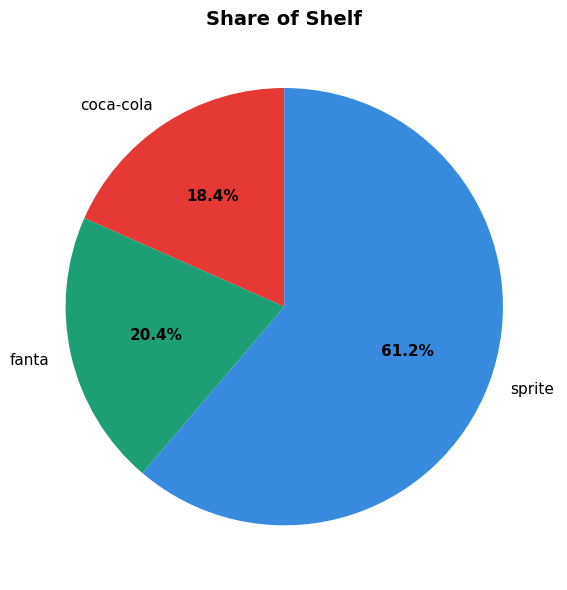

Saved: sos.png


In [8]:
brand_count = sum(1 for d in detections if d["class"] == OUR_BRAND)
comp_count  = sum(1 for d in detections if d["class"] in COMPETITORS)
total_count = brand_count + comp_count

comp_breakdown = {}
for d in detections:
    if d["class"] in COMPETITORS:
        comp_breakdown[d["class"]] = comp_breakdown.get(d["class"], 0) + 1

sos = brand_count / total_count * 100 if total_count > 0 else 0

print("=" * 45)
print("SHARE OF SHELF (SOS)")
print("=" * 45)
print(f"  {OUR_BRAND:<18}: {brand_count} facings")
for name, cnt in comp_breakdown.items():
    print(f"  {name:<18}: {cnt} facings")
print(f"  {'Total':<18}: {total_count} facings")
print(f"  SOS              : {sos:.1f}%")
print("=" * 45)
print("  Formula: coke facings / total facings x 100")

if sos >= 50:   print("  Status: GOOD — brand dominates shelf")
elif sos >= 30: print("  Status: FAIR — brand has reasonable presence")
else:           print("  Status: POOR — brand is underrepresented")

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
labels = [OUR_BRAND] + list(comp_breakdown.keys())
sizes  = [brand_count] + list(comp_breakdown.values())
colors = ["#E53935", "#1D9E75", "#378ADD", "#EF9F27"][:len(labels)]
_, _, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                          autopct="%1.1f%%", startangle=90,
                          textprops={"fontsize": 11})
for at in autotexts:
    at.set_fontweight("bold")
ax.set_title("Share of Shelf", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sos.png")

### Step 5 — Define your planogram
Edit the grid below to match your planned shelf layout.

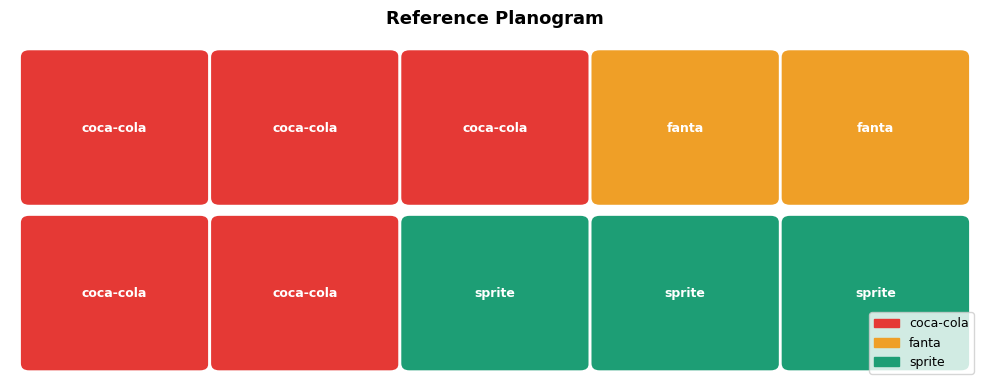

Planogram defined: 2 rows x 5 cols
Coke positions   : 5


In [9]:
# Each (row, col) maps to a product name
# Row 0 = top row, Col 0 = leftmost column
# Use exact names: "coca-cola", "fanta", "sprite", or None for empty

PLANOGRAM = {
    (0, 0): "coca-cola",
    (0, 1): "coca-cola",
    (0, 2): "coca-cola",
    (0, 3): "fanta",
    (0, 4): "fanta",
    (1, 0): "coca-cola",
    (1, 1): "coca-cola",
    (1, 2): "sprite",
    (1, 3): "sprite",
    (1, 4): "sprite",
}

COLOR_MAP = {"coca-cola": "#E53935", "fanta": "#EF9F27", "sprite": "#1D9E75"}

fig, ax = plt.subplots(figsize=(10, 4))
for row in range(GRID_ROWS):
    for col in range(GRID_COLS):
        product = PLANOGRAM.get((row, col))
        color   = COLOR_MAP.get(product, "#CCCCCC")
        ax.add_patch(patches.FancyBboxPatch(
            (col, GRID_ROWS-row-1), 0.9, 0.85,
            boxstyle="round,pad=0.05",
            facecolor=color, edgecolor="white", linewidth=2))
        ax.text(col+0.45, GRID_ROWS-row-1+0.42,
                product if product else "—",
                ha="center", va="center", fontsize=9,
                color="white", fontweight="bold")

ax.set_xlim(-0.1, GRID_COLS)
ax.set_ylim(-0.1, GRID_ROWS)
ax.set_title("Reference Planogram", fontsize=13, fontweight="bold")
ax.axis("off")
ax.legend(handles=[patches.Patch(color=c, label=n) for n,c in COLOR_MAP.items()],
          loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("planogram_ref.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Planogram defined: {GRID_ROWS} rows x {GRID_COLS} cols")
print(f"Coke positions   : {sum(1 for v in PLANOGRAM.values() if v == OUR_BRAND)}")

### Step 6 — Planogram compliance

PLANOGRAM COMPLIANCE
  Total cells    : 10
  Matching       : 3
  Compliance     : 30.0%
  Status         : POOR

  Mismatches:
    Row 1 Col 1: expected coca-cola but found fanta
    Row 1 Col 2: expected coca-cola but found sprite
    Row 1 Col 3: expected coca-cola but found not detected
    Row 1 Col 4: expected fanta but found sprite
    Row 2 Col 1: expected coca-cola but found sprite
    Row 2 Col 2: expected coca-cola but found sprite
    Row 2 Col 4: expected sprite but found coca-cola


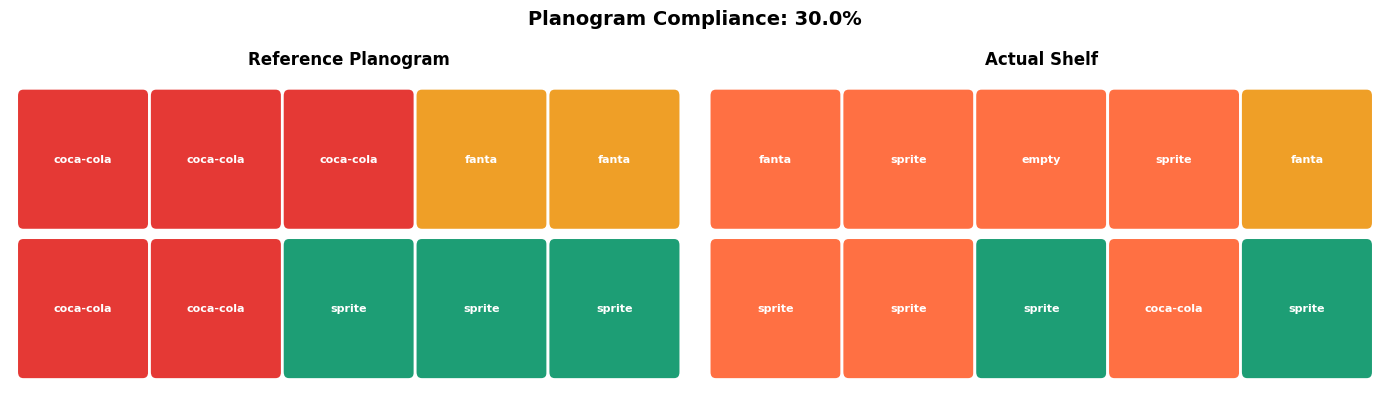

Saved: compliance.png
Orange cells = mismatches


In [11]:
# Assign each detection to a grid cell
cell_w = img_w / GRID_COLS
cell_h = img_h / GRID_ROWS

cell_products = {(r,c): [] for r in range(GRID_ROWS) for c in range(GRID_COLS)}
for d in detections:
    col = min(int(d["center_x"] / cell_w), GRID_COLS-1)
    row = min(int(d["center_y"] / cell_h), GRID_ROWS-1)
    cell_products[(row, col)].append(d["class"])

actual_grid = {}
for cell, products in cell_products.items():
    actual_grid[cell] = max(set(products), key=products.count) if products else None

# Compare to planogram
total_cells    = GRID_ROWS * GRID_COLS
matching_cells = 0
mismatches     = []

for row in range(GRID_ROWS):
    for col in range(GRID_COLS):
        expected = PLANOGRAM.get((row, col))
        actual   = actual_grid.get((row, col))
        if expected == actual:
            matching_cells += 1
        else:
            mismatches.append({
                "pos":      "Row " + str(row+1) + " Col " + str(col+1),
                "expected": expected if expected else "empty",
                "actual":   actual   if actual   else "not detected",
            })

compliance = matching_cells / total_cells * 100

print("=" * 45)
print("PLANOGRAM COMPLIANCE")
print("=" * 45)
print("  Total cells    : " + str(total_cells))
print("  Matching       : " + str(matching_cells))
print("  Compliance     : " + str(round(compliance, 1)) + "%")
print("=" * 45)

if   compliance >= 80: status = "EXCELLENT"
elif compliance >= 60: status = "GOOD"
elif compliance >= 40: status = "FAIR"
else:                  status = "POOR"
print("  Status         : " + status)

if mismatches:
    print("\n  Mismatches:")
    for m in mismatches:
        print("    " + m["pos"] + ": expected " + m["expected"] + " but found " + m["actual"])

# Side by side visual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax_i, (title, grid) in enumerate([("Reference Planogram", PLANOGRAM),
                                        ("Actual Shelf",        actual_grid)]):
    ax = axes[ax_i]
    for row in range(GRID_ROWS):
        for col in range(GRID_COLS):
            product  = grid.get((row, col))
            expected = PLANOGRAM.get((row, col))
            if ax_i == 1:
                color = COLOR_MAP.get(product, "#CCCCCC") if product == expected else "#FF7043"
            else:
                color = COLOR_MAP.get(product, "#CCCCCC")
            ax.add_patch(patches.FancyBboxPatch(
                (col, GRID_ROWS-row-1), 0.9, 0.85,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor="white", linewidth=2))
            ax.text(col+0.45, GRID_ROWS-row-1+0.42,
                    product if product else "empty",
                    ha="center", va="center", fontsize=8,
                    color="white", fontweight="bold")
    ax.set_xlim(-0.1, GRID_COLS)
    ax.set_ylim(-0.1, GRID_ROWS)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")

fig.suptitle("Planogram Compliance: " + str(round(compliance, 1)) + "%", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("compliance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: compliance.png")
print("Orange cells = mismatches")

### Step 7 — Recommendations

RECOMMENDATIONS
  1. Add coca-cola at: Row 1 Col 1, Row 1 Col 2, Row 1 Col 3, Row 2 Col 1, Row 2 Col 2
     Fixing this gains +50.0% compliance
  2. Replace 'sprite' with 'fanta' at Row 1 Col 4
  3. Replace 'coca-cola' with 'sprite' at Row 2 Col 4
  4. Fill empty slots at: Row 1 Col 3

  Current compliance : 30.0%
  After all fixes    : 100.0%
  Gain               : +70.0%


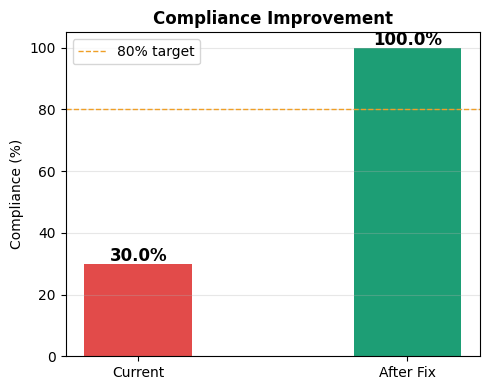

Saved: improvement.png


In [12]:
print("=" * 45)
print("RECOMMENDATIONS")
print("=" * 45)

if not mismatches:
    print("  Perfect compliance — no changes needed.")
else:
    rec = 1
    missing_brand = [m for m in mismatches if m["expected"] == OUR_BRAND]
    wrong_product = [m for m in mismatches if m["expected"] != OUR_BRAND
                     and "not detected" not in m["actual"]]
    empty_slots   = [m for m in mismatches if "not detected" in m["actual"]]

    if missing_brand:
        positions = ", ".join([m["pos"] for m in missing_brand])
        print(f"  {rec}. Add {OUR_BRAND} at: {positions}")
        print(f"     Fixing this gains +{len(missing_brand)/total_cells*100:.1f}% compliance")
        rec += 1

    for m in wrong_product:
        print(f"  {rec}. Replace '{m['actual']}' with '{m['expected']}' at {m['pos']}")
        rec += 1

    if empty_slots:
        positions = ", ".join([m["pos"] for m in empty_slots])
        print(f"  {rec}. Fill empty slots at: {positions}")
        rec += 1

    potential = (matching_cells + len(mismatches)) / total_cells * 100
    print()
    print(f"  Current compliance : {compliance:.1f}%")
    print(f"  After all fixes    : {potential:.1f}%")
    print(f"  Gain               : +{potential-compliance:.1f}%")
    print("=" * 45)

    # Chart
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(["Current", "After Fix"], [compliance, potential],
           color=["#E24B4A", "#1D9E75"], width=0.4)
    ax.set_ylim(0, 105)
    ax.set_ylabel("Compliance (%)")
    ax.set_title("Compliance Improvement", fontweight="bold")
    for x, val in enumerate([compliance, potential]):
        ax.text(x, val+1, f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
    ax.axhline(80, color="#EF9F27", linestyle="--", linewidth=1, label="80% target")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("improvement.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: improvement.png")

### Step 8 — Download all outputs

In [ ]:
import zipfile
from google.colab import files

zip_path = "ShelfSight_Results.zip"
outputs  = ["detected.png", "sos.png", "planogram_ref.png",
            "compliance.png", "improvement.png"]

with zipfile.ZipFile(zip_path, "w") as zf:
    for f in outputs:
        if Path(f).exists():
            zf.write(f)
            print(f"Added: {f}")

files.download(zip_path)
print("Downloaded:", zip_path)